<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/Predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Big Data Analytics and Text Mining Course -> 6 CFU

Safoura Banihashemi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## requirements

In [ ]:
!pip install pyspark

In [ ]:
import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}\n")

Spark version: 4.0.2



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
# from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, ChiSqSelector
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, NaiveBayes, LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, UnivariateFeatureSelector

## Data Loading & Exploration

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_news_popularity = fetch_ucirepo(id=332)

# data (as pandas dataframes)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

print(f"The number of samples: {X.shape[0]}")
print(f"The number of features: {X.shape[1]}")

The number of samples: 39644
The number of features: 58


In [ ]:
print(f"Feature list: {X.columns}")

Feature list: Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_p

In [ ]:
# Merge into one pandas frame
df = pd.concat([X, y], axis=1)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [ ]:
# Print some samples
df.head(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [ ]:
# Check for any nulls across the entire dataset at once
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


In [ ]:
# Check if there are any duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
# Convert to float
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Count difference
deleted_rows = len(X) - len(df)
print(f"Number of deleted samples: {deleted_rows}")

Number of deleted samples: 0


## Convert to binary classification task

In [ ]:
# Calculate the median of the target variable
median_shares = df['shares'].median()
print(f"The median number of shares is: {median_shares}")

The median number of shares is: 1400.0


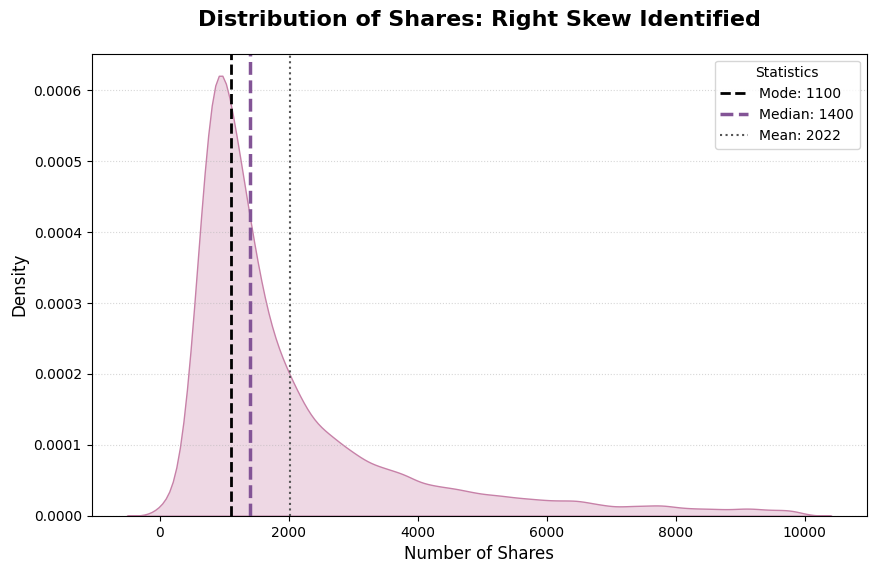

In [ ]:
# Filter out
filtered_y = df[df['shares'] < 10000]['shares'].copy()

# Calculate the statistical points
mean_val = filtered_y.mean()
median_val = filtered_y.median() # This should be ~1400
mode_val = filtered_y.mode()[0]  # Take the first mode if multiple exist

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Generate the Smooth Curve
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)

# Add vertical dashed lines for statistical points
# Mode line (Black, thick)
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
# Median line (Purple, thick)
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
# Mean line (Dark grey, thin)
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')

# Formatting & Labels
ax.set_title("Distribution of Shares: Right Skew Identified", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Shares", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Set the background to clean white and add subtle gridlines
ax.set_facecolor('white')
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Place the legend
ax.legend(title="Statistics")

plt.show()

In [ ]:
# Binary label: popular = shares >= 1400 (median threshold)
THRESHOLD = 1400
df["label"] = (df["shares"] >= THRESHOLD).astype(int)
df.drop(columns=["shares"], inplace=True)

counts = df["label"].value_counts()
total = len(df)

print(counts)
print(f"\nPopular news:   {(counts[1]/total):.2%}")
print(f"\nUnpopular news: {(counts[0]/total):.2%}")

label
1    21154
0    18490
Name: count, dtype: int64

Popular news:   53.36%

Unpopular news: 46.64%


In [ ]:
# Print some samples
df.head(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


In [ ]:
# Push to Spark
sdf = spark.createDataFrame(df)
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

root
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: double (nullable = true)
 |-- kw_max_min: double (nullable = true)
 |-- kw_avg_min: double (nullable = true)
 |-- kw_min_max: double (nullab

## Exploratory Data Analysis (EDA)

In [ ]:
# DataFrame shape
print(f"DataFrame shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nTarget types = {df['label'].dtype}")

DataFrame shape: 39644 rows, 59 columns

Target types = int64


In [ ]:
# Get a statistical summary (min, max, mean, standard deviation)
df.describe()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,0.533599
std,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,0.498876
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,0.000000
50%,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,4.664082,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1.000000
75%,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,4.854839,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,1.000000
max,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,8.041534,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,1.000000


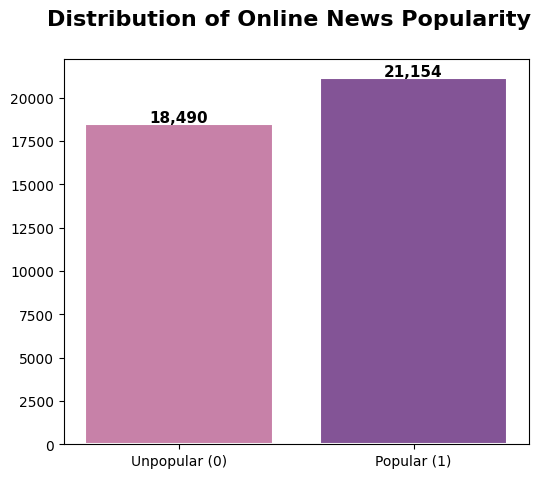

In [ ]:
# Initialize the plot
fig, ax = plt.subplots(figsize=(6, 5))
# Color plot
PALETTE = ["#C781A8", "#835496"]

# Add subtitle
fig.suptitle("Distribution of Online News Popularity", fontsize=16, fontweight="bold")

counts = df["label"].value_counts().sort_index()
ax.bar(["Unpopular (0)", "Popular (1)"], counts.values,
            color=PALETTE, edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

## Pearson Correlation (r)

Pearson Correlation is a way to calculate the pairwise correlation between a single target (label) and a set of other variables.

Mathematically, it measures the linear relationship between two variables, $X$ (feature) and $Y$ (label), using this formula:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$

- Numerator (Covariance): It checks if $X$ and $Y$ move together. If $X$ is above its mean when $Y$ is also above its mean, the correlation goes up.

- Denominator (Normalization): It divides by the product of the standard deviations. This "squashes" the result into a range between -1.0 and +1.0.

- The results:

  - +1.0: Perfect positive linear relationship.

  - 1.0: Perfect negative linear relationship.

  - 0: No linear relationship at all.

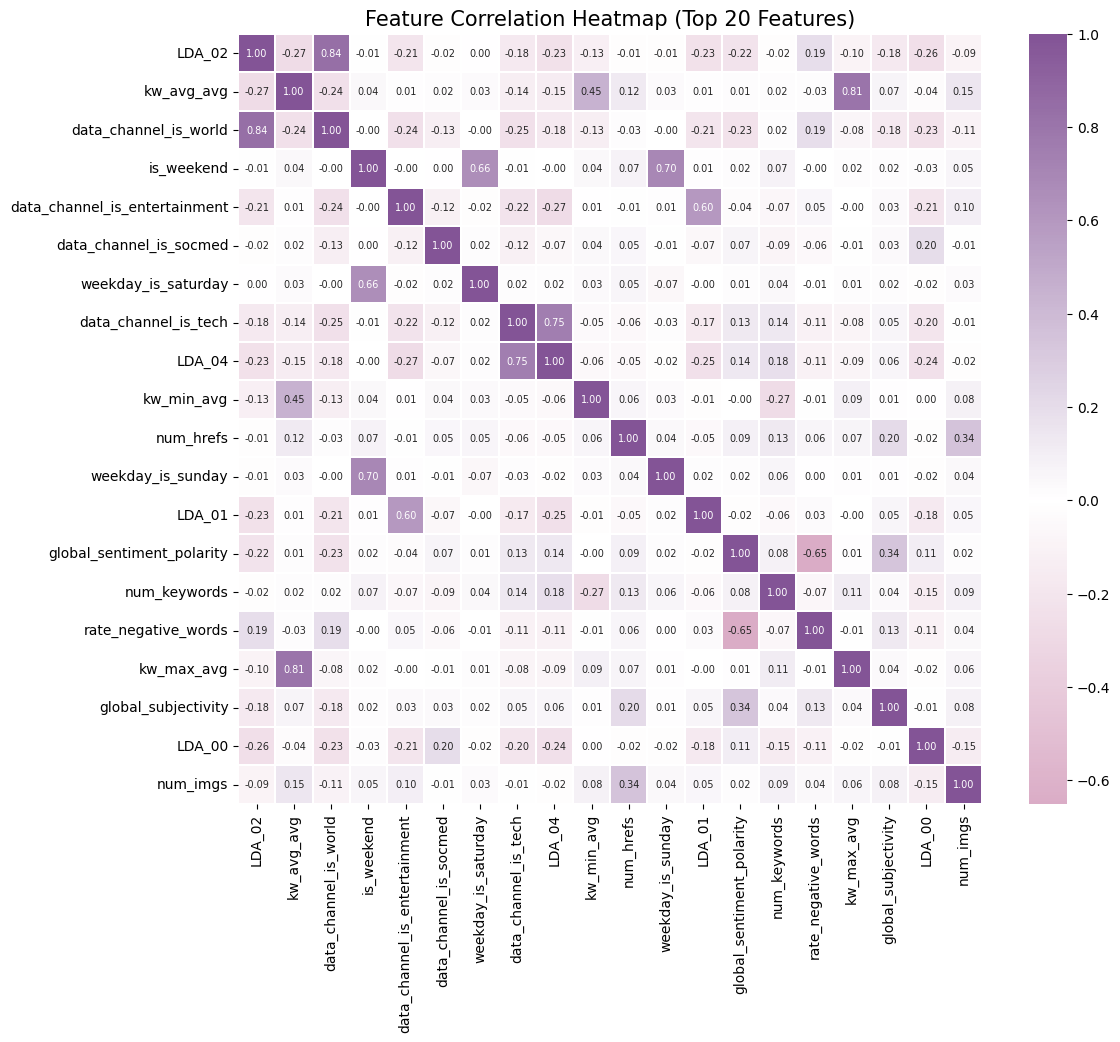

In [ ]:
# feature matrix
feature_list = [col for col in df.columns if col != "label"]

# Identify top 20 features correlated with the label
label_corr = df[feature_list].corrwith(df["label"]).abs().nlargest(20)
top20_features = label_corr.index.tolist()

# Create the Heatmap
colors = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(12, 10))

# Calculate correlation matrix for only the top 20 features
sub_corr = df[top20_features].corr()

sns.heatmap(sub_corr,
            cmap=cmap,
            center=0,
            linewidths=0.3,
            annot=True,     # to see the numbers
            fmt=".2f",      # Rounds numbers to 2 decimal places
            annot_kws={"size": 7})

plt.title("Feature Correlation Heatmap (Top 20 Features)", fontsize=15)
plt.show()

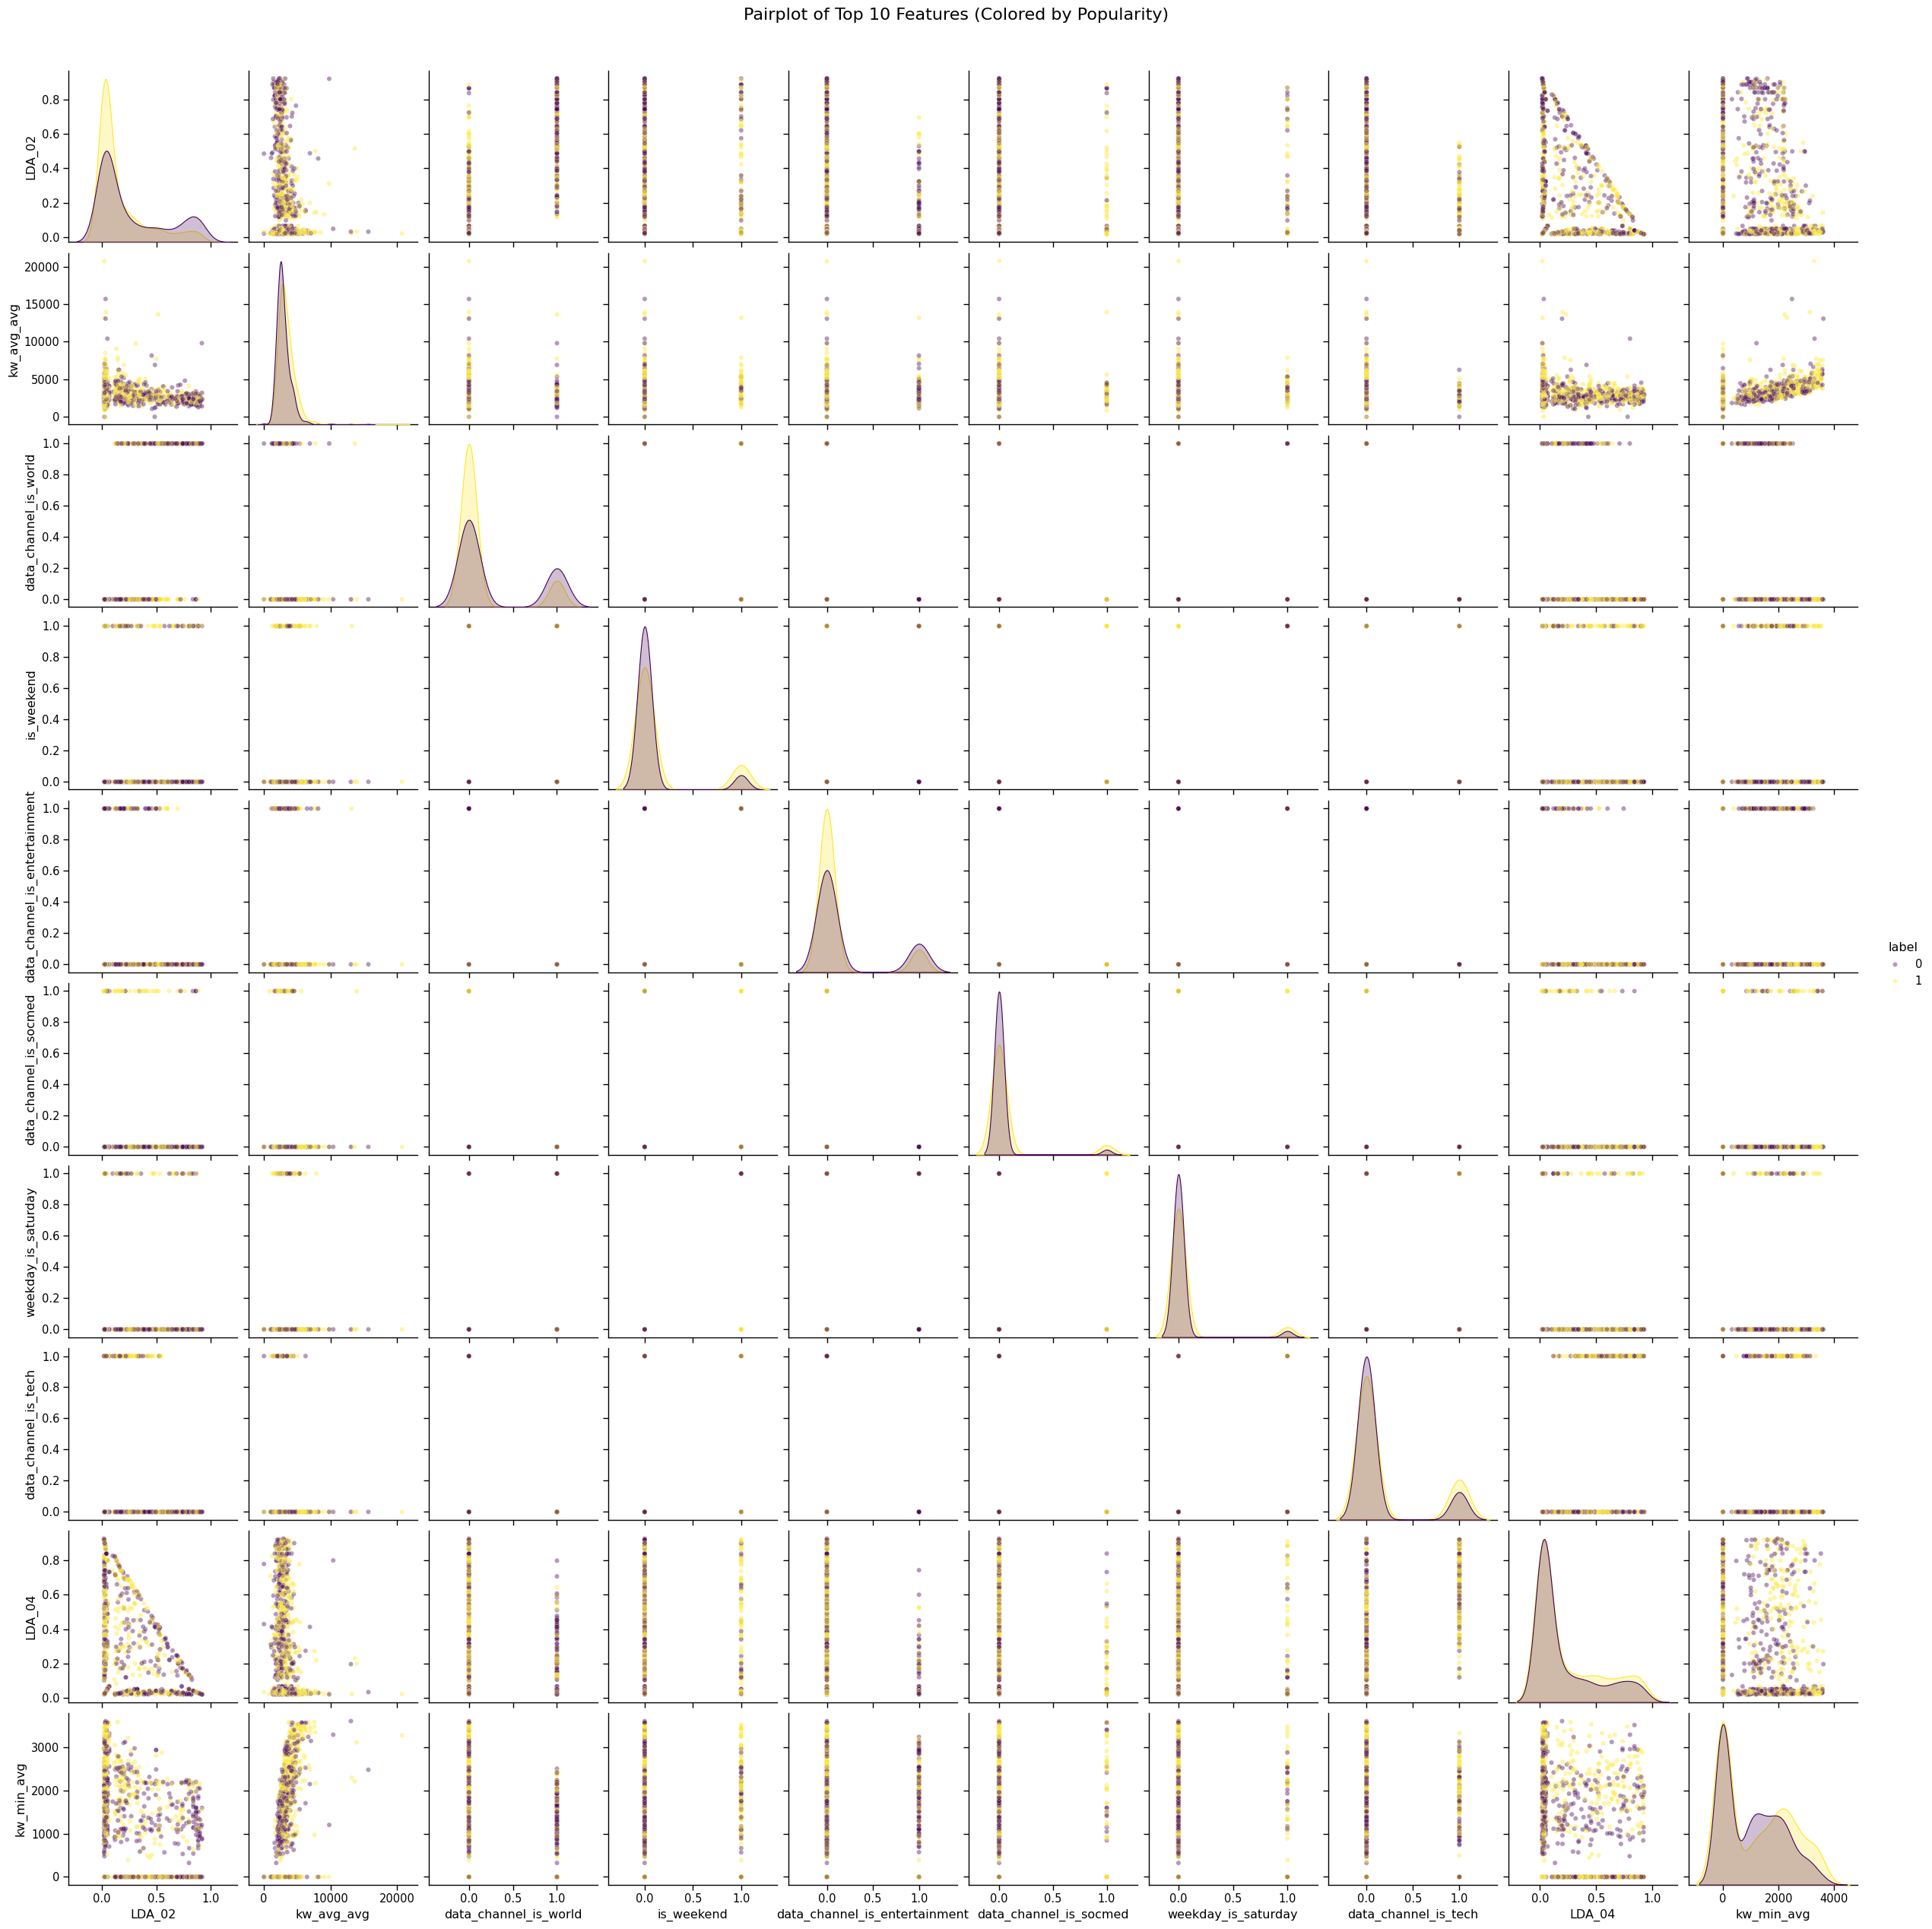

In [ ]:
# Select top 10 features
top10_features = top20_features[:10]

# Add 'label' to the list to use for coloring the points
plot_cols = top10_features + ['label']

# Create the Pairplot
# We take a sample of 1000-2000 points so the plot renders quickly
sns.set_context("paper", font_scale=1.2)
g = sns.pairplot(
    df[plot_cols].sample(1500, random_state=42),
    hue='label',
    palette={0: "#440154", 1: "#FDE725"}, # Consistent with your purple theme
    diag_kind='kde', # Shows the distribution curve on the diagonal
    plot_kws={'alpha': 0.4, 's': 20}
)

g.fig.suptitle("Pairplot of Top 10 Features (Colored by Popularity)", y=1.02, fontsize=16)
plt.show()

## Relative Difference

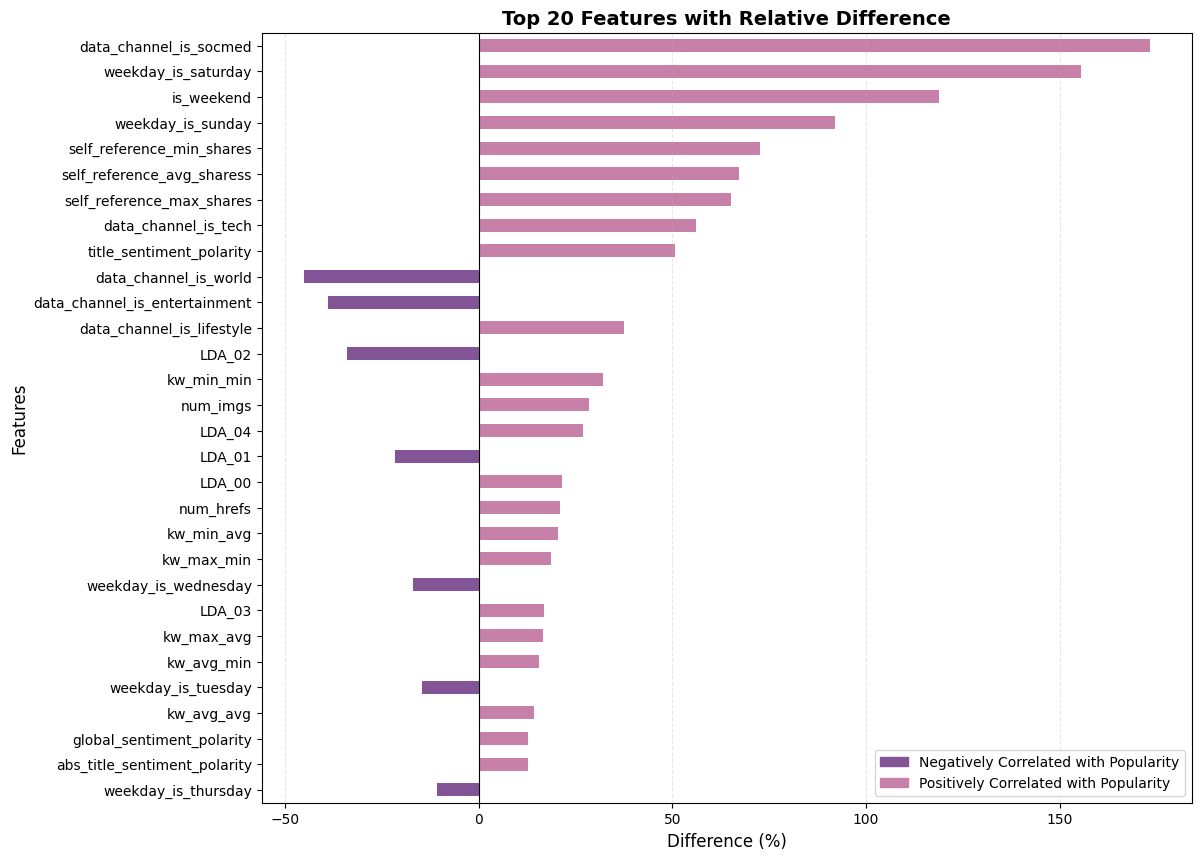

In [ ]:
unpopular = df[df['label'] == 0].mean()
popular = df[df['label'] == 1].mean()

class_diff = pd.DataFrame({
    'Mean_Unpopular': unpopular,
    'Mean_Popular': popular
})

class_diff['Diff (%)'] = ((class_diff['Mean_Popular'] - class_diff['Mean_Unpopular']) / class_diff['Mean_Unpopular']) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()

# Delete label if exist (it is not feature)
if 'label' in class_diff.index:
    class_diff = class_diff.drop('label')

# Initialize the plot
plt.figure(figsize=(12, 10))

# Identify top 20 features with absolute difference
top20_diff = class_diff.sort_values('Abs_Diff', ascending=False).head(30)

# Set color
colors = np.where(top20_diff['Diff (%)'] > 0, PALETTE[0], PALETTE[1])

#
top20_diff['Diff (%)'].plot(kind='barh', color=colors)

#
plt.title('Top 20 Features with Relative Difference', fontsize=14, fontweight='bold')
plt.xlabel('Difference (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)

#
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)

#
plt.gca().invert_yaxis()

# ایجاد راهنمای نمودار متناسب با پالت صورتی و بنفش
purple_patch = mpatches.Patch(color='#835496', label='Negatively Correlated with Popularity')
pink_patch = mpatches.Patch(color='#C781A8', label='Positively Correlated with Popularity')

# اضافه کردن به نمودار
plt.legend(handles=[purple_patch, pink_patch], loc='lower right', fontsize=10)

## Feature selection

In [ ]:
# Correlation pre-filter
corr_with_label = (
    df.drop(columns=["label"])
    .corrwith(df["label"]).abs()
    .sort_values(ascending=False)
)
feature_cols = [c for c in sdf.columns if c != "label"]
pre_filtered = corr_with_label[corr_with_label > 0.01].index.tolist()
print(f"Pre-filter (|corr| > 0.01): {len(feature_cols)} → {len(pre_filtered)} features")

Pre-filter (|corr| > 0.01): 58 → 48 features


In [ ]:
# Assembler & Scaler (defined once, reused everywhere)
# [F9] scaler is part of pre_stages so all training pipelines scale correctly
assembler = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features",
    withMean=True, withStd=True
)

# ── 4c. Sample for sweep ──────────────────────────────────
# [F3] 35 % sample → val set ≈ 7 k rows (was ~1.6 k at 20 %)
# [F4] split computed ONCE outside the loop — same train/val every iteration
sdf_sample = sdf.sample(fraction=0.35, seed=42)
train_s, val_s = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Sweep sample: train={train_s.count():,}  val={val_s.count():,}")

# ── 4d. ANOVA sweep ───────────────────────────────────────
# [F1] UnivariateFeatureSelector with featureType=continuous,
#      labelType=categorical → ANOVA F-test (correct for this data)
# [F2] Pipeline order: assemble → scale → select → LR
# [F5] Improvement guard (+0.0001) prevents selecting larger k on noise
# [F6] 58 added to probe near-full pre-filtered set
# [F12] regParam=0.01 matches downstream grid for fair comparison
k_candidates = [20, 30, 40, 48]
auc_scores   = {}
best_k, best_auc = 0, 0.0

print("\nSweeping features via UnivariateFeatureSelector (ANOVA) + Scaled LR AUC:")
for k in k_candidates:
    selector_sweep = UnivariateFeatureSelector(
        featuresCol="scaled_features",
        outputCol="sel_features",
        labelCol="label",
        selectionMode="numTopFeatures"
    )
    selector_sweep.setFeatureType("continuous") \
                  .setLabelType("categorical")  \
                  .setSelectionThreshold(k)

    lr_tmp = LogisticRegression(
        featuresCol="sel_features", labelCol="label",
        maxIter=20, regParam=0.01          # [F12]
    )
    # [F2] correct order
    pipe_tmp = Pipeline(stages=[assembler, scaler, selector_sweep, lr_tmp])

    model_tmp = pipe_tmp.fit(train_s)
    preds_tmp = model_tmp.transform(val_s)
    ev = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    auc = ev.evaluate(preds_tmp)
    auc_scores[k] = auc
    print(f"  k={k:3d}  AUC={auc:.4f}")

    if auc > (best_auc + 0.0001):        # [F5]
        best_auc, best_k = auc, k

print(f"\n✔ Best k = {best_k}  (AUC = {best_auc:.4f})")
print(
    f"  Reasoning: k={best_k} maximises validation AUC via ANOVA F-test ranking "
    f"of continuous features against the binary label. The +0.0001 guard prevents "
    f"selecting a larger k purely due to sampling noise."
)

Sweep sample: train=11,228  val=2,693

Sweeping features via UnivariateFeatureSelector (ANOVA) + Scaled LR AUC:
  k= 20  AUC=0.6874
  k= 30  AUC=0.6897
  k= 40  AUC=0.6996
  k= 48  AUC=0.7000

✔ Best k = 48  (AUC = 0.7000)
  Reasoning: k=48 maximises validation AUC via ANOVA F-test ranking of continuous features against the binary label. The +0.0001 guard prevents selecting a larger k purely due to sampling noise.


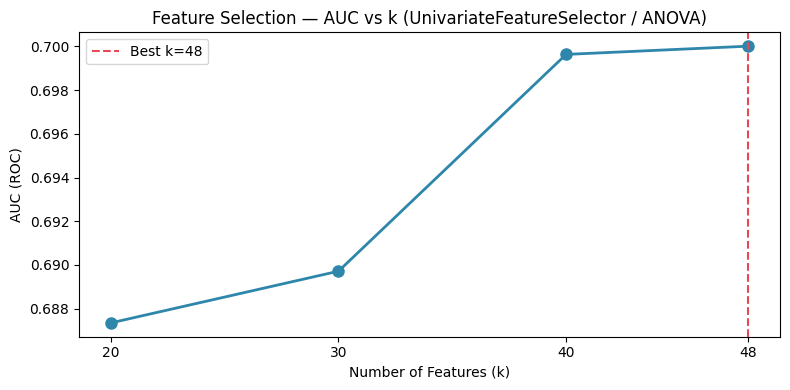

In [ ]:
# ── 4e. Plot AUC vs k ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(auc_scores.keys()), list(auc_scores.values()),
        marker="o", color="#2E86AB", linewidth=2, markersize=8)
ax.axvline(best_k, color="#E84855", linestyle="--", label=f"Best k={best_k}")
ax.set_title("Feature Selection — AUC vs k (UnivariateFeatureSelector / ANOVA)")  # [F11]
ax.set_xlabel("Number of Features (k)")
ax.set_ylabel("AUC (ROC)")
ax.legend()
ax.set_xticks(k_candidates)
plt.tight_layout()
plt.show()

In [ ]:
# Assembler & Scaler (defined once, reused everywhere)
# [F9] scaler is part of pre_stages so all training pipelines scale correctly
assembler = VectorAssembler(
    inputCols=feature_cols, outputCol="raw_features", handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features",
    withMean=True, withStd=True
)

# ── 4c. Sample for sweep ──────────────────────────────────
# [F3] 35 % sample → val set ≈ 7 k rows (was ~1.6 k at 20 %)
# [F4] split computed ONCE outside the loop — same train/val every iteration
sdf_sample = sdf.sample(fraction=0.35, seed=42)
train_s, val_s = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Sweep sample: train={train_s.count():,}  val={val_s.count():,}")

# ── 4d. ANOVA sweep ───────────────────────────────────────
# [F1] UnivariateFeatureSelector with featureType=continuous,
#      labelType=categorical → ANOVA F-test (correct for this data)
# [F2] Pipeline order: assemble → scale → select → LR
# [F5] Improvement guard (+0.0001) prevents selecting larger k on noise
# [F6] 58 added to probe near-full pre-filtered set
# [F12] regParam=0.01 matches downstream grid for fair comparison
k_candidates = [20, 30, 40, 50, 58]
auc_scores   = {}
best_k, best_auc = 0, 0.0

print("\nSweeping features via UnivariateFeatureSelector (ANOVA) + Scaled LR AUC:")
for k in k_candidates:
    selector_sweep = UnivariateFeatureSelector(
        featuresCol="scaled_features",
        outputCol="sel_features",
        labelCol="label",
        selectionMode="numTopFeatures"
    )
    selector_sweep.setFeatureType("continuous") \
                  .setLabelType("categorical")  \
                  .setSelectionThreshold(k)

    lr_tmp = LogisticRegression(
        featuresCol="sel_features", labelCol="label",
        maxIter=20, regParam=0.01          # [F12]
    )
    # [F2] correct order
    pipe_tmp = Pipeline(stages=[assembler, scaler, selector_sweep, lr_tmp])

    model_tmp = pipe_tmp.fit(train_s)
    preds_tmp = model_tmp.transform(val_s)
    ev = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    auc = ev.evaluate(preds_tmp)
    auc_scores[k] = auc
    print(f"  k={k:3d}  AUC={auc:.4f}")

    if auc > (best_auc + 0.0001):        # [F5]
        best_auc, best_k = auc, k

print(f"\n✔ Best k = {best_k}  (AUC = {best_auc:.4f})")
print(
    f"  Reasoning: k={best_k} maximises validation AUC via ANOVA F-test ranking "
    f"of continuous features against the binary label. The +0.0001 guard prevents "
    f"selecting a larger k purely due to sampling noise."
)


Sweeping features via UnivariateFeatureSelector (ANOVA) + Scaled LR AUC:
  k= 20  AUC=0.6874
  k= 30  AUC=0.6921
  k= 40  AUC=0.7017
  k= 50  AUC=0.7011
  k= 58  AUC=0.7015

✔ Best k = 40  (AUC = 0.7017)
  Reasoning: k=40 maximises validation AUC via ANOVA F-test ranking of continuous features against the binary label. The +0.0001 guard prevents selecting a larger k purely due to sampling noise.


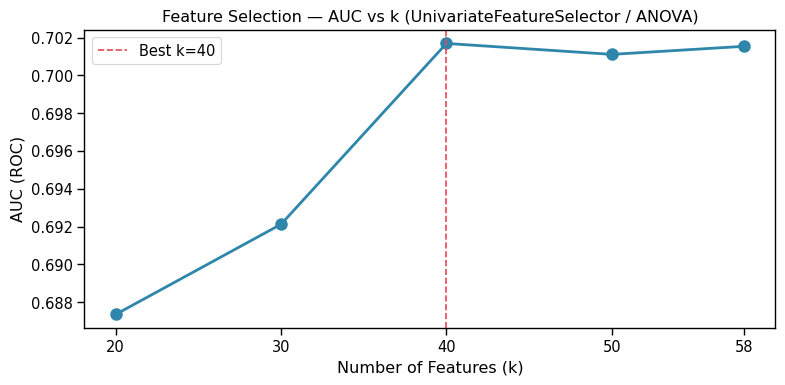

In [ ]:
# ── 4e. Plot AUC vs k ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(auc_scores.keys()), list(auc_scores.values()),
        marker="o", color="#2E86AB", linewidth=2, markersize=8)
ax.axvline(best_k, color="#E84855", linestyle="--", label=f"Best k={best_k}")
ax.set_title("Feature Selection — AUC vs k (UnivariateFeatureSelector / ANOVA)")  # [F11]
ax.set_xlabel("Number of Features (k)")
ax.set_ylabel("AUC (ROC)")
ax.legend()
ax.set_xticks(k_candidates)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4f. Final selector used in all training pipelines ─────
selector_final = UnivariateFeatureSelector(
    featuresCol="scaled_features",
    outputCol="features",
    labelCol="label",
    selectionMode="numTopFeatures"
)
selector_final.setFeatureType("continuous") \
              .setLabelType("categorical")  \
              .setSelectionThreshold(best_k)

# [F9] pre_stages now correctly includes scaler
pre_stages = [assembler, scaler, selector_final]

In [ ]:
# 1. Get the fitted selector stage from your model
# (Stage 2 because your pipeline is: 0:Assembler, 1:Scaler, 2:Selector, 3:LR)
fitted_selector = model_tmp.stages[2]

# 2. Get the indices of the selected features
selected_indices = fitted_selector.selectedFeatures

# 3. Map indices back to the 'pre_filtered' list names
final_feature_names = [pre_filtered[i] for i in selected_indices]

print(f"The {len(final_feature_names)} features selected are:")
print(final_feature_names)

The 48 features selected are:
['LDA_02', 'kw_avg_avg', 'data_channel_is_world', 'is_weekend', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'weekday_is_saturday', 'data_channel_is_tech', 'LDA_04', 'kw_min_avg', 'num_hrefs', 'weekday_is_sunday', 'LDA_01', 'num_keywords', 'kw_max_avg', 'LDA_03', 'self_reference_avg_sharess', 'LDA_00', 'rate_negative_words', 'global_subjectivity', 'self_reference_max_shares', 'global_sentiment_polarity', 'self_reference_min_shares', 'num_imgs', 'title_sentiment_polarity', 'global_rate_positive_words', 'abs_title_sentiment_polarity', 'num_self_hrefs', 'weekday_is_tuesday', 'max_positive_polarity', 'kw_avg_min', 'weekday_is_wednesday', 'kw_min_min', 'average_token_length', 'title_subjectivity', 'n_tokens_title', 'data_channel_is_lifestyle', 'kw_max_min', 'weekday_is_monday', 'avg_positive_polarity', 'n_tokens_content', 'rate_positive_words', 'global_rate_negative_words', 'kw_max_max', 'kw_avg_max', 'weekday_is_thursday', 'min_positive_polarity'

In [ ]:
for col in df.columns:
    if col not in final_feature_names:
        print(col)

n_unique_tokens
n_non_stop_words
n_non_stop_unique_tokens
num_videos
data_channel_is_bus
kw_min_max
avg_negative_polarity
min_negative_polarity
max_negative_polarity
abs_title_subjectivity
label


/tmp/ipykernel_23814/1120640671.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, ax=axes[i, 0], palette="Set2")
/tmp/ipykernel_23814/1120640671.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, ax=axes[i, 0], palette="Set2")
/tmp/ipykernel_23814/1120640671.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feature, ax=axes[i, 0], palette="Set2")
/tmp/ipykernel_23814/1120640671.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is depre

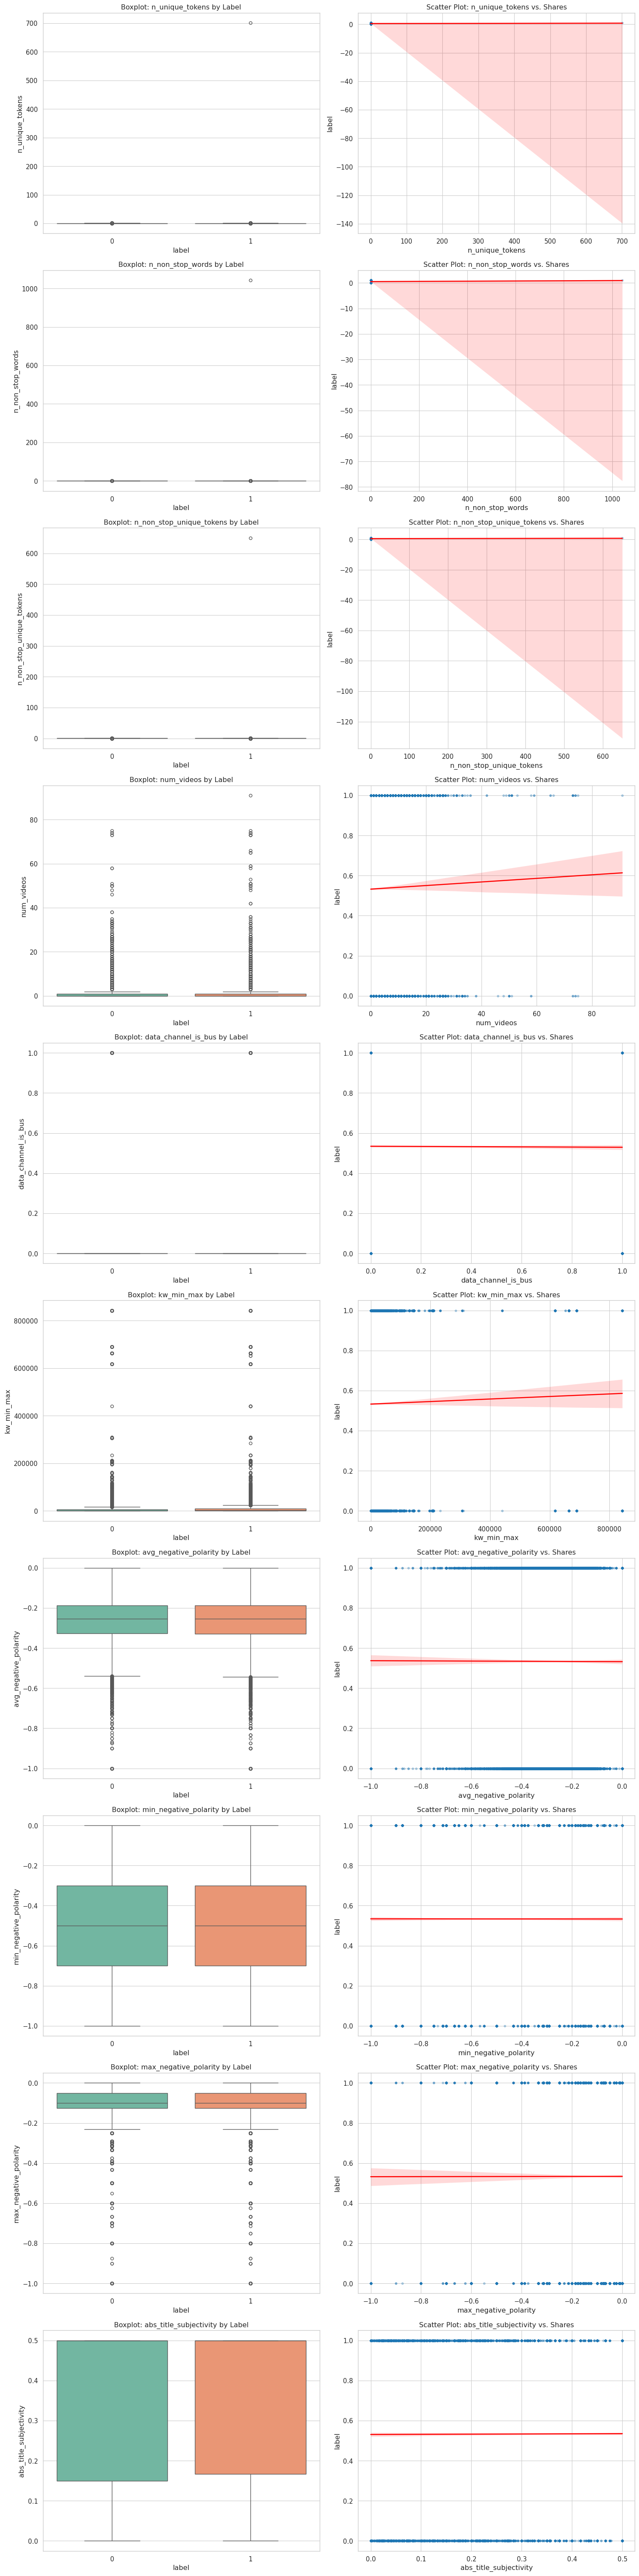

In [ ]:
# Define the noisy features list
noisy_features = [
    'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
    'num_videos', 'data_channel_is_bus', 'kw_min_max',
    'avg_negative_polarity', 'min_negative_polarity',
    'max_negative_polarity', 'abs_title_subjectivity'
]

# Set up the plotting grid (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(15, 60))
sns.set_style("whitegrid")

for i, feature in enumerate(noisy_features):
    # --- Box Plot (Distribution check) ---
    # Good for categorical noise like 'data_channel_is_bus'
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i, 0], palette="Set2")
    axes[i, 0].set_title(f"Boxplot: {feature} by Label")

    # --- Scatter Plot (Linearity/Correlation check) ---
    # Using 'shares' for scatter plot often shows noise better than the binary 'label'
    sns.regplot(data=df, x=feature, y='label', ax=axes[i, 1],
                scatter_kws={'alpha':0.3, 's':10},
                line_kws={'color':'red'})
    axes[i, 1].set_title(f"Scatter Plot: {feature} vs. Shares")

plt.tight_layout()
plt.show()

## Rolling-Window Time-Series Split

Unlike a standard cross-validation where data is shuffled randomly, this method respects the temporal order.



In [ ]:
from pyspark.sql.functions import row_number, col as scol
from pyspark.sql.window import Window

# 1. Force a single partition to ensure a perfect 0, 1, 2... sequence
# Then use row_number() over an empty window (since it's already sorted)
sdf_ordered = sdf.coalesce(1).withColumn("row_num", row_number().over(Window.orderBy(scol(sdf.columns[1]).desc())))

# 2. Convert to 0-based index to match your logic
sdf_ordered = sdf_ordered.withColumn("row_num", scol("row_num") - 1)

sdf_ordered.cache()
total_rows = sdf_ordered.count()
print(f"Total rows with perfect indexing: {total_rows}")

W = 20_000          # base window = train + eval
L =  3_000          # step size = test size
TRAIN_FRAC = 0.70   # fraction of W used for training (rest = eval/CV)
total_window = W + L

num_windows = (total_rows - total_window) // L + 1
print(f"\nWindow parameters:")
print(f"  W (train+eval) : {W:,}  →  train={int(W*TRAIN_FRAC):,}  eval={int(W*(1-TRAIN_FRAC)):,}")
print(f"  L (step=test)  : {L:,}")
print(f"  Total window   : {total_window:,}  (W + L)")
print(f"  Number of windows: {num_windows}")
print(f"\n  Rationale: W=20k gives rich training history; L=3k yields")
print(f"  statistically stable test-set metrics (~3k rows). Friend's")
print(f"  L=1k is too thin for reliable AUC estimates per fold.\n")

Total rows with perfect indexing: 39644

Window parameters:
  W (train+eval) : 20,000  →  train=14,000  eval=6,000
  L (step=test)  : 3,000
  Total window   : 23,000  (W + L)
  Number of windows: 6

  Rationale: W=20k gives rich training history; L=3k yields
  statistically stable test-set metrics (~3k rows). Friend's
  L=1k is too thin for reliable AUC estimates per fold.



In [ ]:
from pyspark.sql.functions import col as scol

splits = []
for i in range(num_windows):
    # 'start' is the 0-based index for the beginning of this window
    start = i * L

    # Training: [start, start + 14,000)
    tr_start = start
    tr_end   = start + int(W * TRAIN_FRAC) - 1

    # Eval: [start + 14,000, start + 20,000)
    ev_start = tr_end + 1
    ev_end   = start + W - 1

    # Test: [start + 20,000, start + 23,000)
    te_start = start + W
    te_end   = start + W + L - 1

    # Final boundary check to avoid exceeding the 39,644 rows
    if te_end >= total_rows:
        te_end = total_rows - 1

    train_fold = sdf_ordered.filter((scol("row_num") >= tr_start) & (scol("row_num") <= tr_end))
    eval_fold  = sdf_ordered.filter((scol("row_num") >= ev_start) & (scol("row_num") <= ev_end))
    test_fold  = sdf_ordered.filter((scol("row_num") >= te_start) & (scol("row_num") <= te_end))

    splits.append((train_fold, eval_fold, test_fold))

    print(f"Fold {i+1:2d}: "
          f"train [{tr_start:6,}-{tr_end:6,}] "
          f"eval [{ev_start:6,}-{ev_end:6,}] "
          f"test [{te_start:6,}-{te_end:6,}] "
          f"| n_train={train_fold.count():5,} "
          f"n_eval={eval_fold.count():5,} "
          f"n_test={test_fold.count():5,}")

Fold  1: train [     0-13,999] eval [14,000-19,999] test [20,000-22,999] | n_train=14,000 n_eval=6,000 n_test=3,000
Fold  2: train [ 3,000-16,999] eval [17,000-22,999] test [23,000-25,999] | n_train=14,000 n_eval=6,000 n_test=3,000
Fold  3: train [ 6,000-19,999] eval [20,000-25,999] test [26,000-28,999] | n_train=14,000 n_eval=6,000 n_test=3,000
Fold  4: train [ 9,000-22,999] eval [23,000-28,999] test [29,000-31,999] | n_train=14,000 n_eval=6,000 n_test=3,000
Fold  5: train [12,000-25,999] eval [26,000-31,999] test [32,000-34,999] | n_train=14,000 n_eval=6,000 n_test=3,000
Fold  6: train [15,000-28,999] eval [29,000-34,999] test [35,000-37,999] | n_train=14,000 n_eval=6,000 n_test=3,000


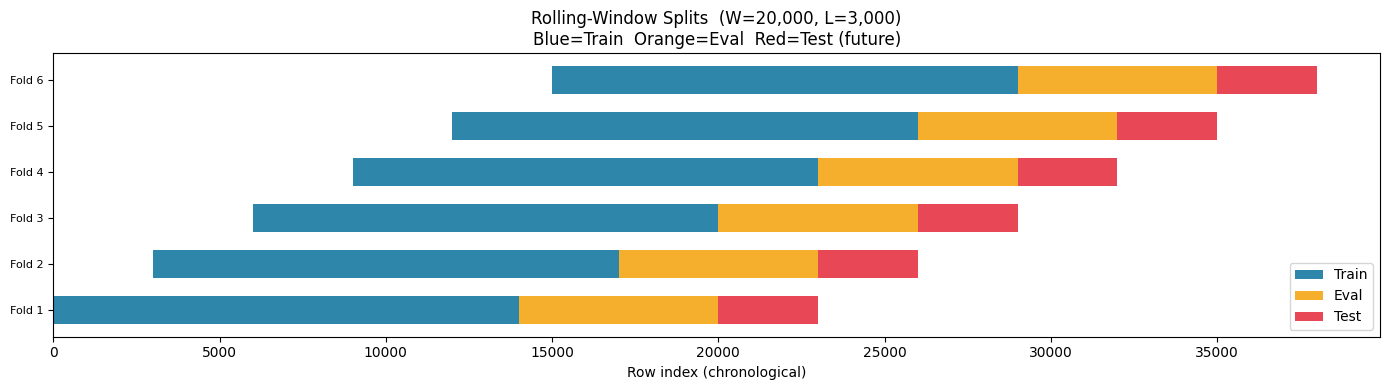

In [ ]:
N_SPLITS = len(splits)
# ── Visualise splits ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(4, N_SPLITS * 0.5)))
for i, (tr, ev, te) in enumerate(splits):
    tr_s = tr.agg(F.min("row_num")).collect()[0][0]
    tr_e = tr.agg(F.max("row_num")).collect()[0][0]
    ev_s = ev.agg(F.min("row_num")).collect()[0][0]
    ev_e = ev.agg(F.max("row_num")).collect()[0][0]
    te_s = te.agg(F.min("row_num")).collect()[0][0]
    te_e = te.agg(F.max("row_num")).collect()[0][0]

    ax.barh(i, tr_e - tr_s, left=tr_s, height=0.6,
            color="#2E86AB", label="Train" if i == 0 else "")
    ax.barh(i, ev_e - ev_s, left=ev_s, height=0.6,
            color="#F6AE2D", label="Eval"  if i == 0 else "")
    ax.barh(i, te_e - te_s, left=te_s, height=0.6,
            color="#E84855", label="Test"  if i == 0 else "")

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)], fontsize=8)
ax.set_xlabel("Row index (chronological)")
ax.set_title(f"Rolling-Window Splits  (W={W:,}, L={L:,})\n"
             f"Blue=Train  Orange=Eval  Red=Test (future)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Model Definitions & Grid Search

In [ ]:
# ── Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,            [50, 100])
    .addGrid(rf.maxDepth,            [5, 10])
    .addGrid(rf.minInstancesPerNode, [1, 5])
    .build()
)

In [ ]:
# ── Gradient Boosted Tree ──────────────────────────────────
gbt = GBTClassifier(featuresCol="features", labelCol="label", seed=42, maxIter=50)
gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

In [ ]:
# ── Logistic Regression ───────────────────────────────────
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build()
)

In [ ]:
# Standard models list
model_configs = [
    ("Random Forest",         rf,  rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
    ("Logistic Regression",   lr,  lr_grid),
]

In [ ]:
# Shared AUC evaluator
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

## Helper Functions

In [ ]:
def compute_metrics(predictions):
    """Return accuracy / F1 / precision / recall / AUC dict."""
    results = {}
    for key, metric in [
        ("accuracy",  "accuracy"),
        ("f1",        "f1"),
        ("precision", "weightedPrecision"),
        ("recall",    "weightedRecall"),
    ]:
        ev = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        )
        results[key] = ev.evaluate(predictions)
    results["auc"] = evaluator_auc.evaluate(predictions)
    return results

In [ ]:
def train_and_evaluate(name, estimator, param_grid,
                       train_sdf, eval_sdf, test_sdf,
                       pipeline_stages=None):
    """
    3-way split workflow matching the W+L design:
      1. CrossValidator selects best hyperparams using train_sdf (internal CV)
      2. Best pipeline is refit on train_sdf + eval_sdf combined (full W)
      3. Final metrics are computed on test_sdf only (L rows = true future)

    This correctly separates hyperparameter tuning (train+eval = W) from
    final evaluation (test = L), preventing any leakage from test into fitting.
    """
    stages   = pre_stages if pipeline_stages is None else pipeline_stages
    pipeline = Pipeline(stages=stages + [estimator])

    # Step 1: grid search on train portion only
    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_auc,
        numFolds=3,
        seed=42,
        parallelism=2,
    )
    print(f"  Fitting {name} …", end=" ", flush=True)
    cv_model = cv.fit(train_sdf)

    # Step 2: refit best pipeline on full W (train + eval combined)
    full_W      = train_sdf.union(eval_sdf)
    final_model = pipeline.fit(full_W)
    print("done.")

    # Step 3: evaluate on held-out test (L rows = true future, never seen)
    preds   = final_model.transform(test_sdf)
    metrics = compute_metrics(preds)
    print(f"  {name}: ACC={metrics['accuracy']:.4f}  "
          f"F1={metrics['f1']:.4f}  AUC={metrics['auc']:.4f}")
    return metrics

## Training over Rolling-Window Folds

In [ ]:
all_results = {name: [] for name, _, _ in model_configs}

for fold_idx, (train_fold, eval_fold, test_fold) in enumerate(splits):
    print(f"\n{'─'*50}")
    print(f"Fold {fold_idx + 1}/{N_SPLITS}")
    print(f"{'─'*50}")

    # Standard models: assemble → StandardScale → ANOVA select → model
    for name, estimator, param_grid in model_configs:
        metrics = train_and_evaluate(
            name, estimator, param_grid,
            train_fold, eval_fold, test_fold
        )
        all_results[name].append(metrics)


──────────────────────────────────────────────────
Fold 1/6
──────────────────────────────────────────────────
  Fitting Random Forest … done.
  Random Forest: ACC=0.6297  F1=0.6216  AUC=0.7000
  Fitting Gradient Boosted Tree … done.
  Gradient Boosted Tree: ACC=0.6523  F1=0.6522  AUC=0.7168
  Fitting Logistic Regression … done.
  Logistic Regression: ACC=0.6493  F1=0.6493  AUC=0.7022

──────────────────────────────────────────────────
Fold 2/6
──────────────────────────────────────────────────
  Fitting Random Forest … done.
  Random Forest: ACC=0.6457  F1=0.6382  AUC=0.7031
  Fitting Gradient Boosted Tree … done.
  Gradient Boosted Tree: ACC=0.6633  F1=0.6621  AUC=0.7103
  Fitting Logistic Regression … done.
  Logistic Regression: ACC=0.6437  F1=0.6438  AUC=0.6932

──────────────────────────────────────────────────
Fold 3/6
──────────────────────────────────────────────────
  Fitting Random Forest … done.
  Random Forest: ACC=0.6337  F1=0.6280  AUC=0.6835
  Fitting Gradient Boosted 

## Aggregate Results

In [ ]:
model_names = list(all_results.keys())
metric_keys = ["accuracy", "f1", "precision", "recall", "auc"]

avg_results = {
    mname: {mk: np.mean([f[mk] for f in all_results[mname]]) for mk in metric_keys}
    for mname in model_names
}

summary_df = pd.DataFrame(avg_results).T[metric_keys]
summary_df.index.name = "Model"
print("\nAverage Metrics across Rolling Folds:")
print(summary_df.round(4).to_string())


Average Metrics across Rolling Folds:
                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6349  0.6273     0.6378  0.6349  0.6860
Gradient Boosted Tree    0.6488  0.6470     0.6481  0.6488  0.7027
Logistic Regression      0.6379  0.6360     0.6375  0.6379  0.6846


## Comparison Plots

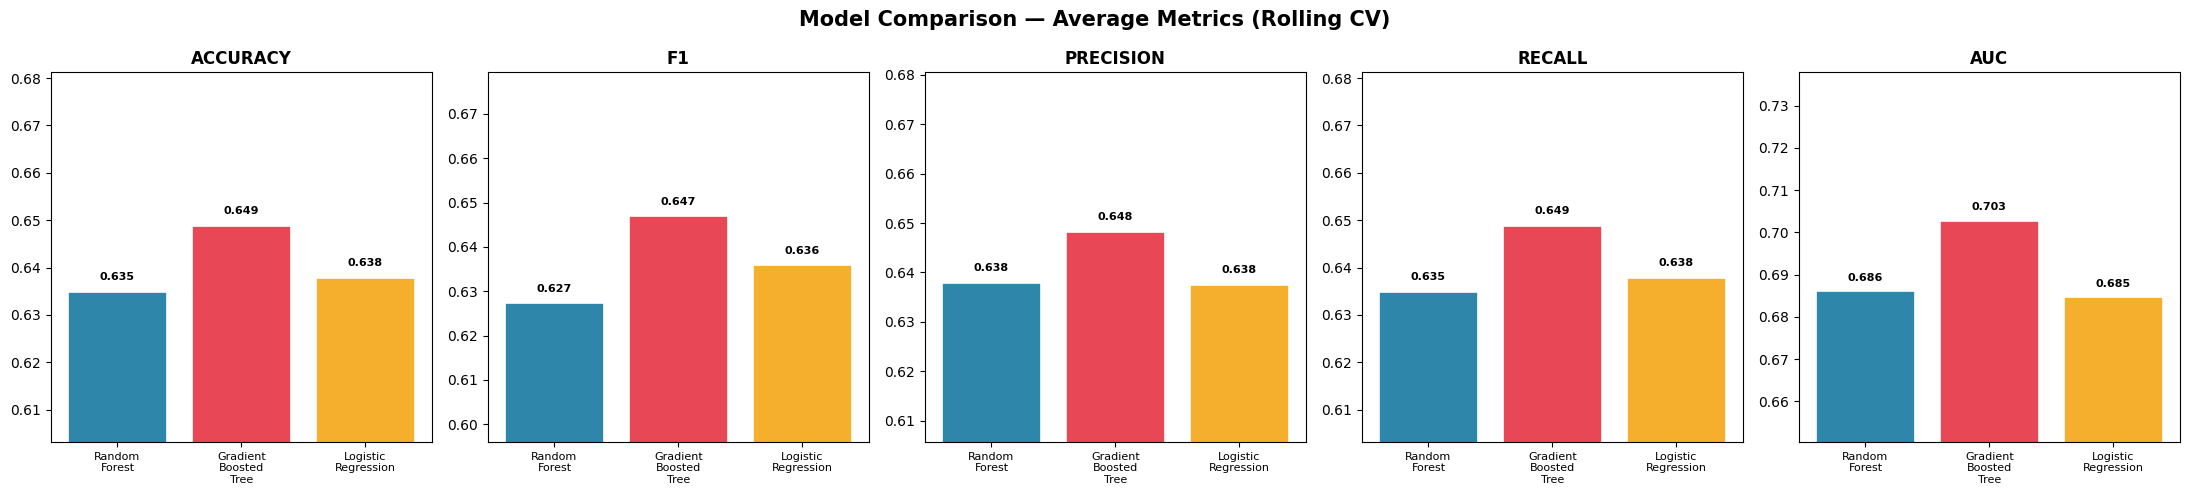

In [ ]:
COLORS       = ["#2E86AB", "#E84855", "#F6AE2D", "#2DC653"]
MODEL_LABELS = [m.replace(" ", "\n") for m in model_names]

# ── 10a. Grouped bar chart ────────────────────────────────
fig, axes = plt.subplots(1, len(metric_keys), figsize=(22, 5))
fig.suptitle("Model Comparison — Average Metrics (Rolling CV)",
             fontsize=15, fontweight="bold")
for ax, mk in zip(axes, metric_keys):
    vals = [avg_results[m][mk] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=COLORS,
                  edgecolor="white", linewidth=1.2)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(MODEL_LABELS, fontsize=8)
    ax.set_title(mk.upper(), fontweight="bold")
    ax.set_ylim(min(vals) * 0.95, max(vals) * 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

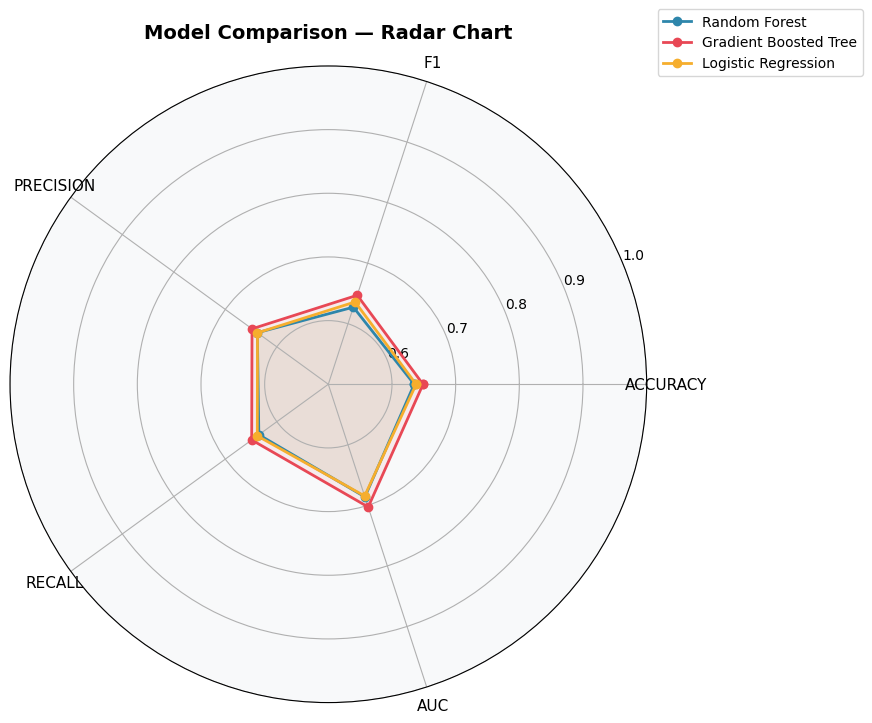

In [ ]:
# ── 10b. Radar chart ──────────────────────────────────────
categories = [m.upper() for m in metric_keys]
N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor("#F8F9FA")
for idx, mname in enumerate(model_names):
    vals = [avg_results[mname][mk] for mk in metric_keys]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=COLORS[idx], label=mname)
    ax.fill(angles, vals, alpha=0.08, color=COLORS[idx])
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison — Radar Chart", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

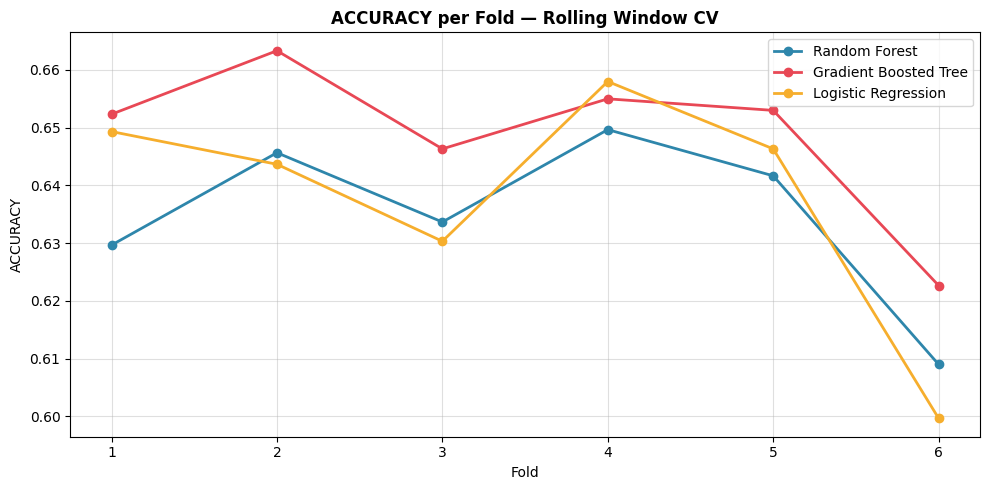

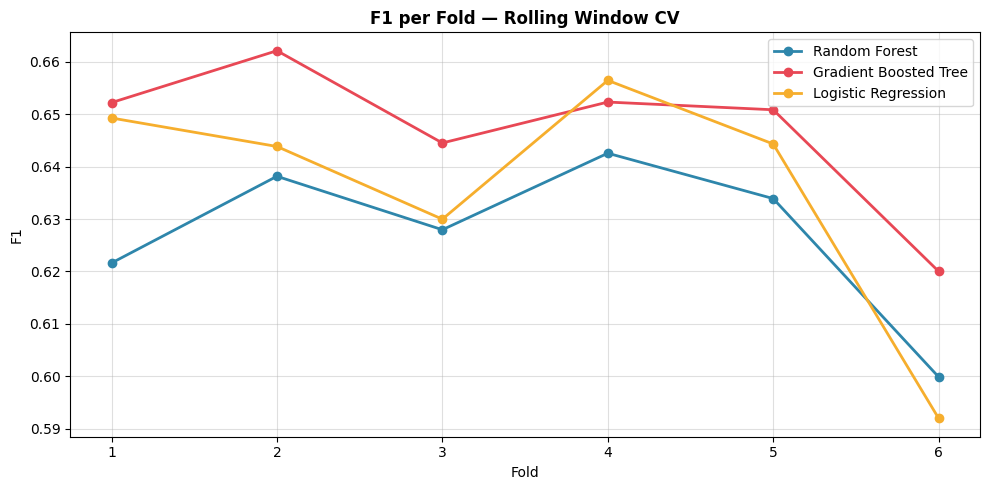

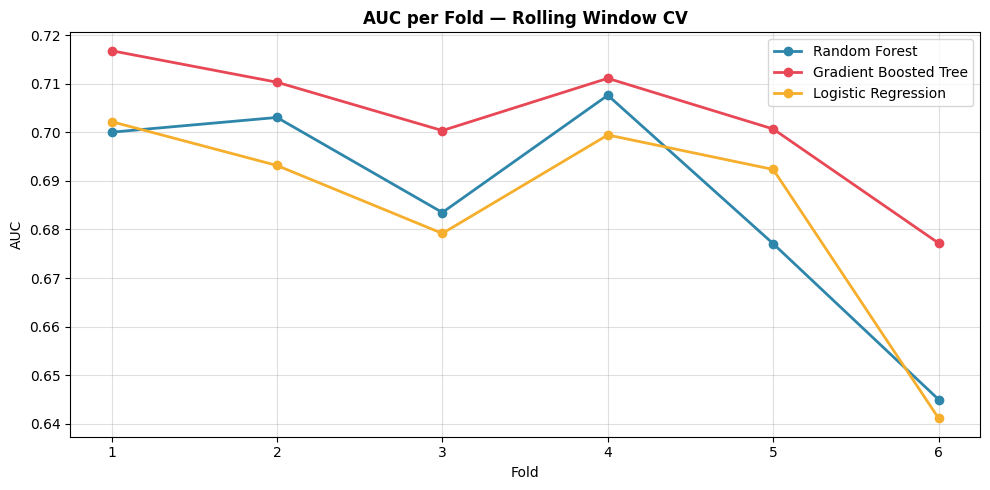

In [ ]:
for mk in ["accuracy", "f1", "auc"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    for idx, mname in enumerate(model_names):
        fold_vals = [f[mk] for f in all_results[mname]]
        ax.plot(range(1, N_SPLITS + 1), fold_vals,
                marker="o", linewidth=2, color=COLORS[idx], label=mname)
    ax.set_title(f"{mk.upper()} per Fold — Rolling Window CV", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(mk.upper())
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

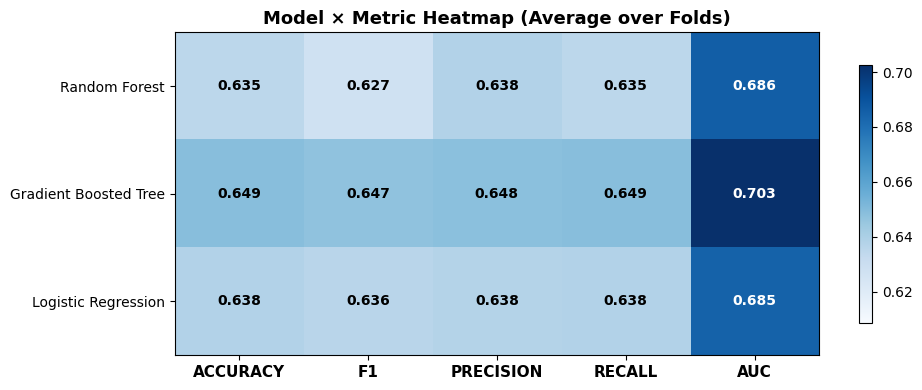

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = summary_df.values.astype(float)
im = ax.imshow(heat_data, cmap="Blues", aspect="auto",
               vmin=heat_data.min() * 0.97, vmax=heat_data.max())
ax.set_xticks(range(len(metric_keys)))
ax.set_xticklabels([m.upper() for m in metric_keys], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)
for i in range(len(model_names)):
    for j in range(len(metric_keys)):
        ax.text(j, i, f"{heat_data[i, j]:.3f}",
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white" if heat_data[i, j] > heat_data.mean() else "black")
ax.set_title("Model × Metric Heatmap (Average over Folds)",
             fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
best_by_f1  = summary_df["f1"].idxmax()
best_by_auc = summary_df["auc"].idxmax()

print(f"\n📊 Summary Table:\n{summary_df.round(4)}")
print(f"\n🏆 Best by F1  : {best_by_f1}   "
      f"(F1={avg_results[best_by_f1]['f1']:.4f})")
print(f"🏆 Best by AUC : {best_by_auc}  "
      f"(AUC={avg_results[best_by_auc]['auc']:.4f})")
print("\nAll plots saved to /mnt/user-data/outputs/")

spark.stop()
print("\n✅ Project complete.")


📊 Summary Table:
                       accuracy      f1  precision  recall     auc
Model                                                             
Random Forest            0.6349  0.6273     0.6378  0.6349  0.6860
Gradient Boosted Tree    0.6488  0.6470     0.6481  0.6488  0.7027
Logistic Regression      0.6379  0.6360     0.6375  0.6379  0.6846

🏆 Best by F1  : Gradient Boosted Tree   (F1=0.6470)
🏆 Best by AUC : Gradient Boosted Tree  (AUC=0.7027)

All plots saved to /mnt/user-data/outputs/

✅ Project complete.
